In [97]:

import cv2
import numpy as np
import matplotlib.pyplot as plt

Image loaded successfully.


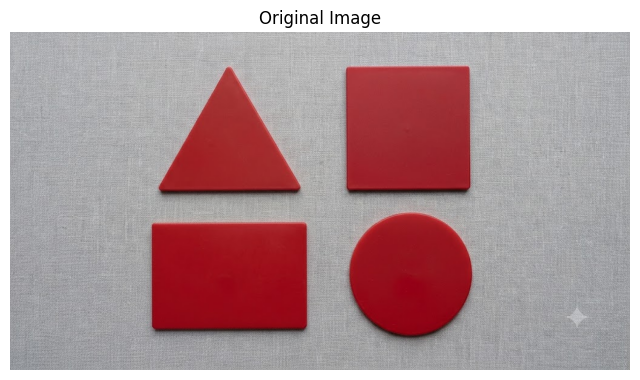

In [106]:
image_path = "/kaggle/input/datasets/sp23bse071/redshape/shape.jpg"   # Change path if needed

image = cv2.imread(image_path)

if image is None:
    print("Image not found. Check the file path.")
else:
    print("Image loaded successfully.")

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,6))
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

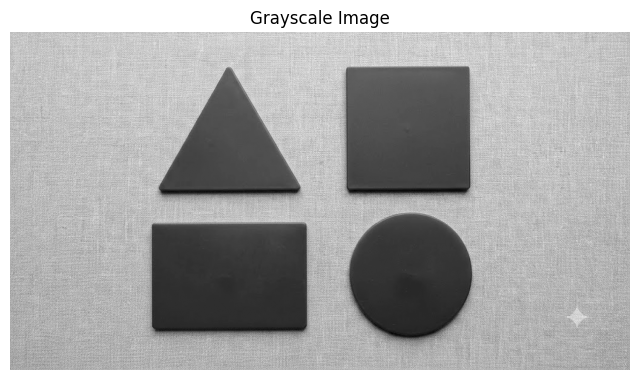

True

In [107]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(8,6))
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

cv2.imwrite("gray_image.png", gray)

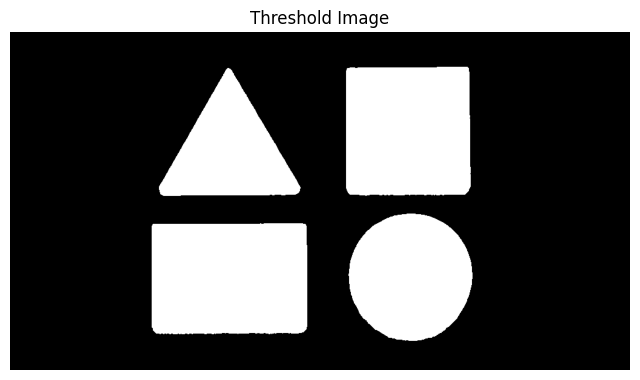

True

In [109]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

blur = cv2.GaussianBlur(gray, (5,5), 0)

_, thresh = cv2.threshold(
    blur,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

plt.figure(figsize=(8,6))
plt.imshow(thresh, cmap="gray")
plt.title("Threshold Image")
plt.axis("off")
plt.show()

cv2.imwrite("threshold_image.png", thresh)

In [110]:
contours, hierarchy = cv2.findContours(
    thresh,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

print("Total Contours Found:", len(contours))

Total Contours Found: 4


In [111]:
contours, hierarchy = cv2.findContours(
    thresh,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

print("Total Contours Found:", len(contours))

Total Contours Found: 4


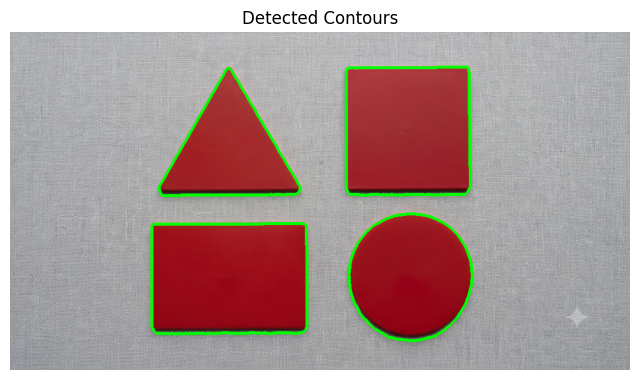

True

In [112]:
contour_image = image.copy()

cv2.drawContours(contour_image, contours, -1, (0,255,0), 3)

plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(contour_image, cv2.COLOR_BGR2RGB))
plt.title("Detected Contours")
plt.axis("off")
plt.show()

cv2.imwrite("contours.png", contour_image)

In [114]:
print("Area and Perimeter of Each Shape\n")

for i, contour in enumerate(contours):

    area = cv2.contourArea(contour)
    perimeter = cv2.arcLength(contour, True)

    print(f"Object {i+1}")
    print(f"Area      : {area:.2f}")
    print(f"Perimeter : {perimeter:.2f}")
    print("-"*30)

Area and Perimeter of Each Shape

Object 1
Area      : 46029.00
Perimeter : 882.65
------------------------------
Object 2
Area      : 33395.50
Perimeter : 688.00
------------------------------
Object 3
Area      : 26310.50
Perimeter : 745.31
------------------------------
Object 4
Area      : 42628.00
Perimeter : 829.20
------------------------------


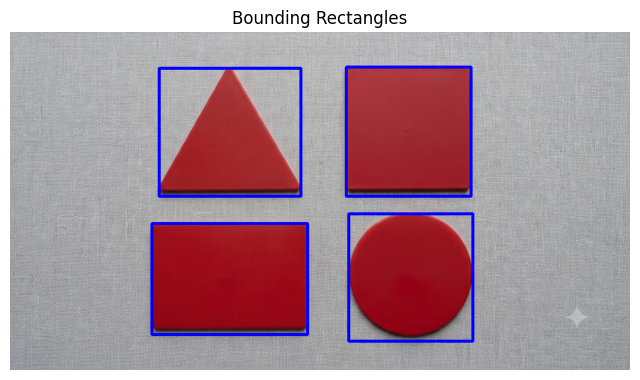

True

In [115]:
bounding_image = image.copy()

for contour in contours:

    x, y, w, h = cv2.boundingRect(contour)

    cv2.rectangle(
        bounding_image,
        (x, y),
        (x + w, y + h),
        (255, 0, 0),
        3
    )

plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(bounding_image, cv2.COLOR_BGR2RGB))
plt.title("Bounding Rectangles")
plt.axis("off")
plt.show()

cv2.imwrite("bounding_rectangles.png", bounding_image)

Detected Shapes

Rectangle
Circle
Triangle
Square


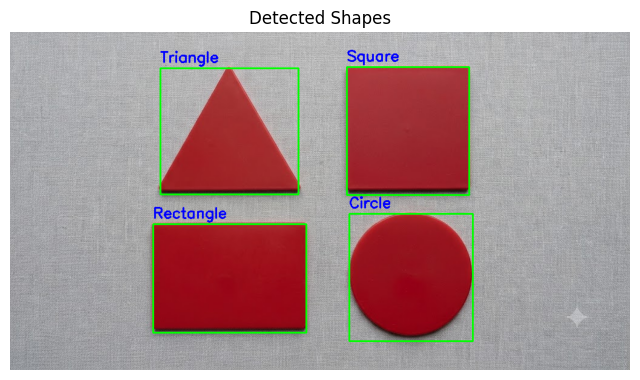

True

In [116]:
shape_image = image.copy()

print("Detected Shapes\n")

for contour in contours:

    area = cv2.contourArea(contour)

    if area < 100:
        continue

    perimeter = cv2.arcLength(contour, True)

    approx = cv2.approxPolyDP(
        contour,
        0.04 * perimeter,
        True
    )

    vertices = len(approx)

    x, y, w, h = cv2.boundingRect(approx)

    if vertices == 3:
        shape = "Triangle"

    elif vertices == 4:

        aspect_ratio = w / float(h)

        if 0.95 <= aspect_ratio <= 1.05:
            shape = "Square"
        else:
            shape = "Rectangle"

    else:
        shape = "Circle"

    print(shape)

    cv2.rectangle(shape_image, (x, y), (x+w, y+h), (0,255,0), 2)

    cv2.putText(
        shape_image,
        shape,
        (x, y-10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255,0,0),
        2
    )

plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(shape_image, cv2.COLOR_BGR2RGB))
plt.title("Detected Shapes")
plt.axis("off")
plt.show()

cv2.imwrite("detected_shapes.png", shape_image)